In [69]:
import numpy as np
import pandas as pd
import arviz as az
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from cmdstanpy import CmdStanModel
from sampler import CycloneDataSimulator

In [70]:
# compile Stan model
model = CmdStanModel(stan_file="conjugate_model.stan")

In [71]:
# prior parameters
a = 3
y_alpha = 3
z_alpha = 2
y_gamma = 3
z_gamma = 2 
v2 = 2
y_lam = 3
z_lam = 1

# model parameters
B = 5               # number of ocean basins
D = 5               # number of predictors

In [72]:
N_big = 2000             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N_big)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params_big = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N_big, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

In [73]:
# fit and sample using Stan model
fit = model.sample(stan_data, iter_warmup=500)
draws_df_big = fit.draws_pd()

20:32:25 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]




chain 1:   7%|▋         | 100/1500 [00:05<01:22, 16.98it/s, (Warmup)]


chain 1:  13%|█▎        | 200/1500 [00:08<00:51, 25.15it/s, (Warmup)]



chain 1:  20%|██        | 300/1500 [00:10<00:37, 31.89it/s, (Warmup)]

chain 1:  27%|██▋       | 400/1500 [00:12<00:28, 39.24it/s, (Warmup)]




chain 1:  33%|███▎      | 500/1500 [00:14<00:23, 42.56it/s, (Sampling)]



chain 1:  40%|████      | 600/1500 [00:16<00:19, 46.42it/s, (Sampling)]


chain 1:  47%|████▋     | 700/1500 [00:17<00:16, 49.40it/s, (Sampling)]


chain 1:  60%|██████    | 900/1500 [00:21<00:11, 52.52it/s, (Sampling)]


chain 1:  67%|██████▋   | 1000/1500 [00:23<00:09, 53.61it/s, (Sampling)]


chain 1:  73%|███████▎  | 1100/1500 [00:27<00:10, 37.51it/s, (Sampling)]


chain 1:  80%|████████  | 1200/1500 [00:29<00:07, 41.58it/s, (Sampling)]


chain 1:  87%|████████▋ | 1300/1500 [00:31<00:04, 45.21it/s, (Sampling)]


chain 1:  93%|█████████▎| 1400/1500 [00:33<00:02, 47.98it/s, (Sampling)]


chain 1: 100%|██████████| 1500/1500 [0


20:33:02 - cmdstanpy - INFO - CmdStan done processing.
20:33:02 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: inv_gamma_lpdf: Scale parameter is 0, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: inv_gamma_lpdf: Shape parameter is inf, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: inv_gamma_lpdf: Shape parameter is 0, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Consider re-running with show_console=True if the above output is unclear!


In [74]:
N_small = 100             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N_small)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params_small = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# load simulated data into a Stan dictionary
stan_basins = basins + 1            # Stan is 1-indexed!!!
stan_data = {
    "N" : N_small, "B" : B, "D" : D,
    "W" : W, "X" : X, "basins" : stan_basins,
    "a" : a,
    "y_alpha" : y_alpha, "z_alpha" : z_alpha,
    "y_gamma" : y_gamma, "z_gamma" : z_gamma,
    "v2" : v2,
    "y_lambda" : y_lam, "z_lambda" : z_lam,
}

In [75]:
# fit and sample using Stan model
fit = model.sample(stan_data, iter_warmup=500)
draws_df_small = fit.draws_pd()

20:33:03 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]




chain 1:   7%|▋         | 100/1500 [00:00<00:02, 509.86it/s, (Warmup)]


chain 1:  13%|█▎        | 200/1500 [00:00<00:02, 509.04it/s, (Warmup)]


chain 1:  20%|██        | 300/1500 [00:00<00:02, 460.91it/s, (Warmup)]


chain 1:  27%|██▋       | 400/1500 [00:00<00:02, 521.70it/s, (Warmup)]


chain 1:  33%|███▎      | 500/1500 [00:00<00:01, 559.19it/s, (Sampling)]





chain 1:  40%|████      | 600/1500 [00:01<00:01, 530.40it/s, (Sampling)]


chain 1:  47%|████▋     | 700/1500 [00:01<00:01, 494.21it/s, (Sampling)]


chain 1:  53%|█████▎    | 800/1500 [00:01<00:01, 472.83it/s, (Sampling)]


chain 1:  60%|██████    | 900/1500 [00:01<00:01, 496.38it/s, (Sampling)]


chain 1:  67%|██████▋   | 1000/1500 [00:02<00:01, 486.88it/s, (Sampling)]


chain 1:  73%|███████▎  | 1100/1500 [00:02<00:00, 469.29it/s, (Sampling)]


chain 1:  80%|████████  | 1200/1500 [00:02<00:00, 478.47it/s, (Sampling)]


chain 1:  87%|████████▋ | 1300/1500 [00:02<00:00, 481.32it/s, (Sampling)]



chain 1:  93%|████████


20:33:07 - cmdstanpy - INFO - CmdStan done processing.
20:33:07 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: inv_gamma_lpdf: Shape parameter is inf, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Exception: inv_gamma_lpdf: Shape parameter is 0, but must be positive finite! (in 'conjugate_model.stan', line 46, column 4 to column 35)
Exception: multi_normal_lpdf: LDLT_Factor of covariance parameter is not positive definite.  last conditional variance is -nan. (in 'conjugate_model.stan', line 48, column 8 to column 93)
Consider re-running with show_console=True if the above output is unclear!


In [76]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]
true_params_big = np.concatenate([np.atleast_1d(p).flatten() for p in real_params_big])
true_params_small = np.concatenate([np.atleast_1d(p).flatten() for p in real_params_small])

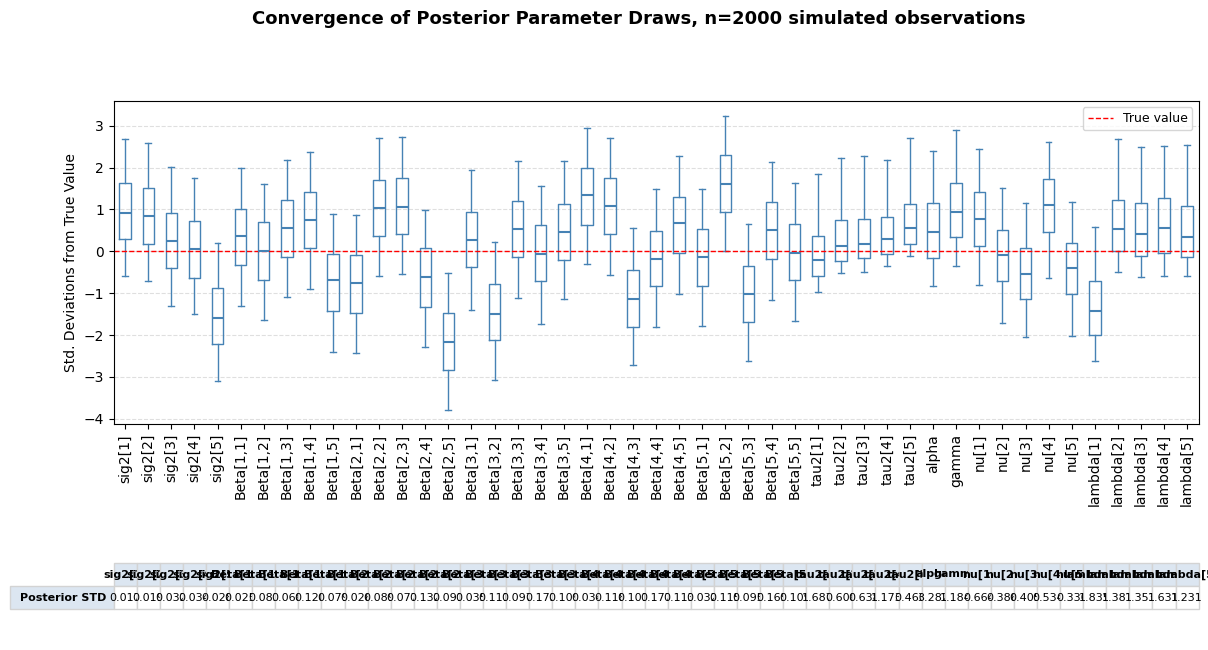

In [77]:
# plot convergence for large data set
all_param_draws = []
param_stds = []
for param, true in zip(param_names, true_params_big):
    # normalizes the draws so that they can all be plotted together
    draws = draws_df_big[param].values[:]
    standardized_draws = (draws - true) / draws.std()
    all_param_draws.append(standardized_draws)
    param_stds.append(draws.std())

# I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
fig = plt.figure(figsize=(14, 7))
fig.suptitle(f"Convergence of Posterior Parameter Draws, n={N_big} simulated observations",
             fontsize=13, fontweight='bold', y=1.01)

# Give boxplot ~75% of height, table ~25%
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.5)
ax = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])

# --- Boxplot ---
ax.boxplot(
    all_param_draws,
    tick_labels=param_names,
    whis=(5, 95),
    showfliers=False,
    # showmeans=True,
    # meanprops=dict(marker='x', markeredgecolor='black', markersize=6, markeredgewidth=1.5),
    medianprops=dict(color='steelblue', linewidth=1.5),
    boxprops=dict(color='steelblue'),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0.5, len(param_names) + 0.5)

# --- Table ---
ax_table.axis('off')
table = ax_table.table(
    cellText=[[f'{s:.3f}' for s in param_stds]],
    colLabels=param_names,
    rowLabels=['Posterior STD'],
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)   # make rows a bit taller

# Style the header cells
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#dce6f1')
        cell.set_text_props(fontweight='bold')
    cell.set_edgecolor('lightgray')
    
plt.show()

Look at prior to posterior reduction in variance vs sample size.

Try fewer observations to test sensitivity to sample size.

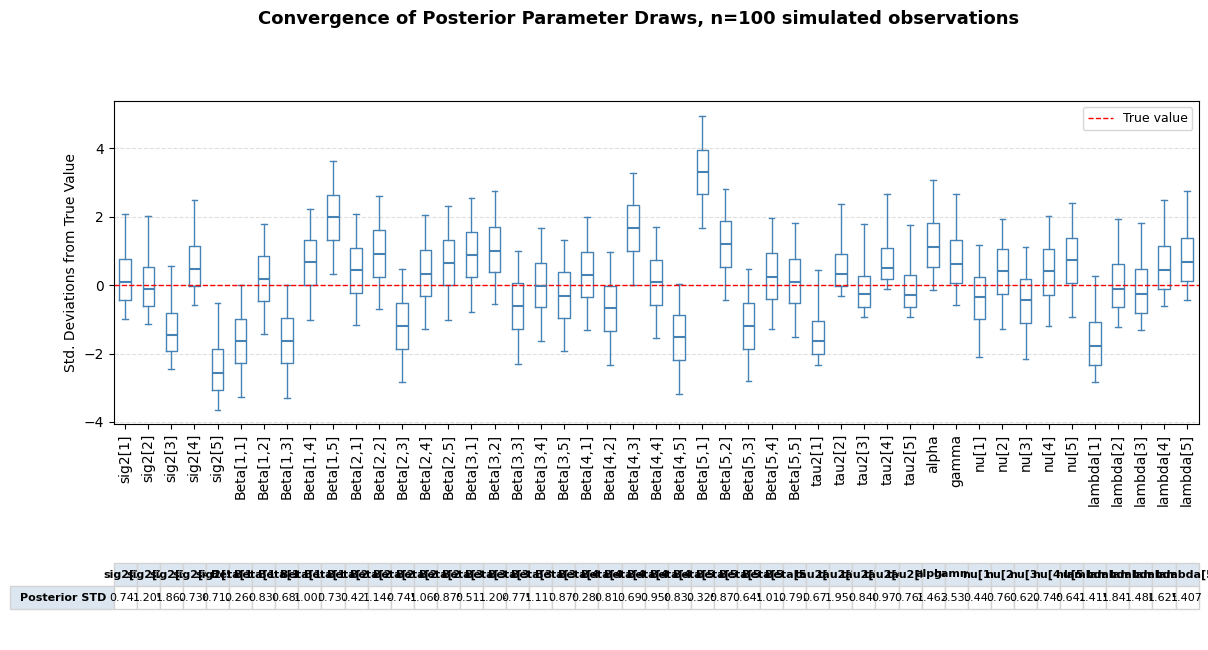

In [78]:
# plot convergence for small datset
all_param_draws = []
param_stds = []
for param, true in zip(param_names, true_params_small):
    # normalizes the draws so that they can all be plotted together
    draws = draws_df_small[param].values[:]
    standardized_draws = (draws - true) / draws.std()
    all_param_draws.append(standardized_draws)
    param_stds.append(draws.std())

# I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
fig = plt.figure(figsize=(14, 7))
fig.suptitle(f"Convergence of Posterior Parameter Draws, n={N_small} simulated observations",
             fontsize=13, fontweight='bold', y=1.01)

# Give boxplot ~75% of height, table ~25%
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.5)
ax = fig.add_subplot(gs[0])
ax_table = fig.add_subplot(gs[1])

# --- Boxplot ---
ax.boxplot(
    all_param_draws,
    tick_labels=param_names,
    whis=(5, 95),
    showfliers=False,
    # showmeans=True,
    # meanprops=dict(marker='x', markeredgecolor='black', markersize=6, markeredgewidth=1.5),
    medianprops=dict(color='steelblue', linewidth=1.5),
    boxprops=dict(color='steelblue'),
    whiskerprops=dict(color='steelblue'),
    capprops=dict(color='steelblue'),
)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(0.5, len(param_names) + 0.5)

# --- Table ---
ax_table.axis('off')
table = ax_table.table(
    cellText=[[f'{s:.3f}' for s in param_stds]],
    colLabels=param_names,
    rowLabels=['Posterior STD'],
    loc='center',
    cellLoc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)   # make rows a bit taller

# Style the header cells
for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor('#dce6f1')
        cell.set_text_props(fontweight='bold')
    cell.set_edgecolor('lightgray')
    
plt.show()

Tabulate results

In [84]:
table_df_big = pd.DataFrame({
    "True Value" : true_params_big, 
    "Posterior Mean" : [draws_df_big[param].mean() for param in param_names],
    "5th Percentile" : [np.percentile(draws_df_big[param].values, 5) for param in param_names],
    "95th Percentile" : [np.percentile(draws_df_big[param].values, 95) for param in param_names]
}, index=param_names)

In [85]:
print(table_df_big.round(4))

           True Value  Posterior Mean  5th Percentile  95th Percentile
sig2[1]        0.2146          0.2312          0.2047           0.2598
sig2[2]        0.2562          0.2727          0.2427           0.3052
sig2[3]        0.4558          0.4648          0.4138           0.5202
sig2[4]        0.4857          0.4884          0.4339           0.5463
sig2[5]        0.4459          0.4028          0.3589           0.4517
Beta[1,1]      2.3331          2.3418          2.3004           2.3832
Beta[1,2]     -1.0024         -1.0020         -1.1381          -0.8686
Beta[1,3]     -1.2089         -1.1717         -1.2822          -1.0607
Beta[1,4]      1.7814          1.8715          1.6719           2.0667
Beta[1,5]      0.7753          0.7182          0.5852           0.8454
Beta[2,1]     -2.2168         -2.2372         -2.2810          -2.1939
Beta[2,2]     -0.2981         -0.2049         -0.3510          -0.0575
Beta[2,3]     -2.7678         -2.6847         -2.8103          -2.5577
Beta[2

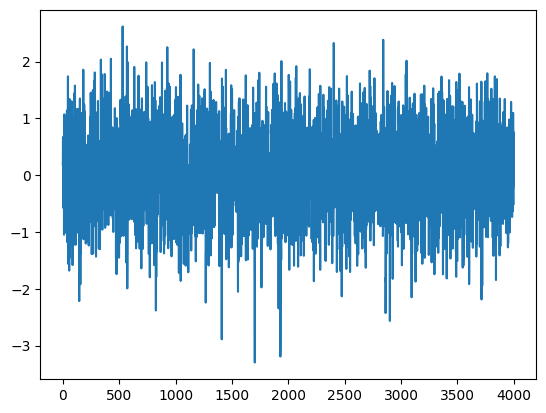

In [81]:
plt.plot(draws_df_small["nu[4]"].values)
plt.show()

In [82]:
print(DataSimulator.sig2)

[2.05739955 3.39850706 7.84552131 1.71472564 3.84103559]
